In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving archive.zip to archive.zip


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
X = df[['Age', 'EstimatedSalary']].values

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X)

In [6]:
df['Cluster'] = clusters

In [7]:
print(pd.crosstab(df['Cluster'], df['Purchased']))

Purchased    0   1
Cluster           
0           11  63
1          150  35
2           96  45


In [9]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

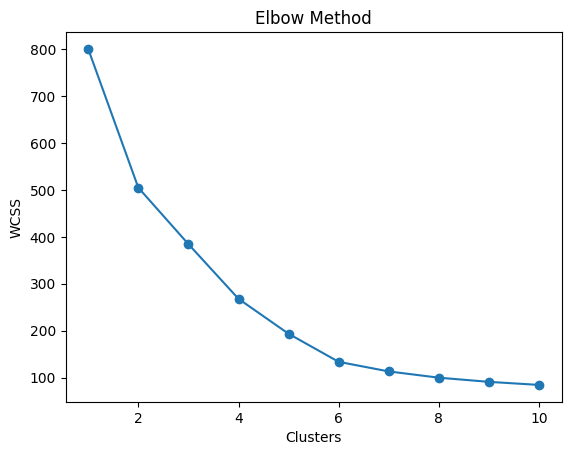

In [10]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

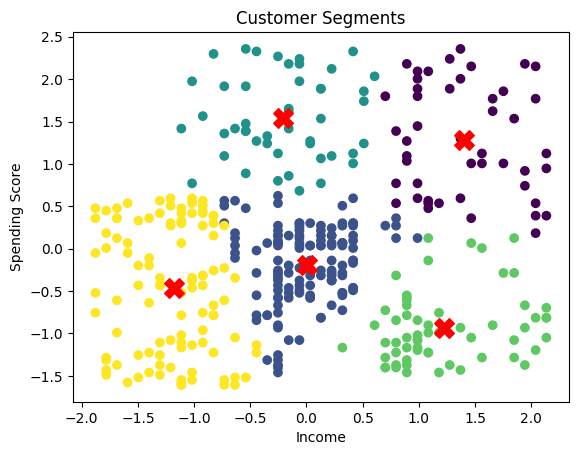

In [12]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X')
plt.title('Customer Segments')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.39331271561400144


In [14]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))

2 0.3829875894215638
3 0.31477770070506567
4 0.34238967519036273
5 0.39331271561400144
6 0.4473291069084066
7 0.4501063572482829
8 0.4047478436770923
9 0.3920099328488487


In [15]:
df['Cluster'] = y_kmeans
print(df['Cluster'].value_counts())

Cluster
1    138
4    108
3     60
2     47
0     47
Name: count, dtype: int64


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_res, y_res = smote.fit_resample(X_scaled, y_kmeans)

In [17]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_res, y_res = rus.fit_resample(X_scaled, y_kmeans)

In [18]:
init='k-means++'

In [19]:
KMeans(n_clusters=5, n_init=10)

KMeans(n_clusters=5, n_init=10)